# Задача 3. Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)

**ФИО:** Непомнящий Матвей Тимофеевич  
**ИСУ:** 507189  
**Группа:** S4102


## Задача

Везде считаем, что вершины графа занумерованы подряд с **нуля**.


## Импорты и загрузка графов

Граф: булева матрица смежности $A$ ($A_{uv}=1$, если есть ребро $u \to v$). Тесты на синтетике и `ca-GrQc`; бенчмарки на SuiteSparse и случайных графах.


In [1]:
%matplotlib inline

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 100

import graphblas as gb
gb.init("suitesparse", blocking=False)

from graphblas import Matrix, Vector, dtypes, binary, monoid, semiring, select
from graphblas.io import mmread
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import urllib.request
import tarfile


In [2]:
import os
import time
import urllib.request
import tarfile


def load_graph(path: str) -> Matrix:
    return mmread(path)


def to_bool_matrix(A: Matrix) -> Matrix:
    n = A.nrows
    rows, cols, _ = A.to_coo()
    return Matrix.from_coo(rows, cols, [True] * len(rows), nrows=n, ncols=n, dtype=dtypes.BOOL)


DOWNLOAD_DIR = "../data/suitesparse"
BASE_URL = "https://suitesparse-collection-website.herokuapp.com/MM"


def download_graph(group: str, name: str) -> str:
    graph_dir = os.path.join(DOWNLOAD_DIR, name)
    mtx_path = os.path.join(graph_dir, f"{name}.mtx")
    if os.path.exists(mtx_path):
        return mtx_path

    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    url = f"{BASE_URL}/{group}/{name}.tar.gz"
    tar_path = os.path.join(DOWNLOAD_DIR, f"{name}.tar.gz")

    print(f"  Downloading {group}/{name} ...")
    urllib.request.urlretrieve(url, tar_path)

    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(DOWNLOAD_DIR)
    os.remove(tar_path)

    if not os.path.exists(mtx_path):
        for root, dirs, files in os.walk(graph_dir):
            for f in files:
                if f.endswith(".mtx"):
                    return os.path.join(root, f)
    return mtx_path


def load_suitesparse_graph(group: str, name: str) -> Matrix:
    mtx_path = download_graph(group, name)
    return to_bool_matrix(mmread(mtx_path))


def generate_random_directed_graph(n: int, density: float, seed: int = 42) -> Matrix:
    from scipy.sparse import random as sp_random
    rng = np.random.default_rng(seed)
    sp = sp_random(n, n, density=density, format="coo", random_state=rng,
                   data_rvs=lambda s: np.ones(s, dtype=np.int64))
    rows, cols = sp.row, sp.col
    mask = rows != cols
    r, c = rows[mask], cols[mask]
    if len(r) == 0:
        return Matrix(dtypes.BOOL, nrows=n, ncols=n)
    return Matrix.from_coo(r.tolist(), c.tolist(), [True] * len(r), nrows=n, ncols=n, dtype=dtypes.BOOL)

GRAPH_ROOT = os.path.abspath(os.path.join("..", "lab_2", "graphs_for_test"))


def load_mtx(rel_path: str) -> Matrix:
    path = os.path.join(GRAPH_ROOT, *rel_path.split("/"))
    return to_bool_matrix(load_graph(path))


## Задание 1

MSBFS-Levels: для каждого источника массив уровней BFS (недостижимые: **−1**). Полукольцо: `lor.land`.

Матрицы `frontier` и `levels` размера $k \times n$: на шаге `frontier = frontier * A`, новым вершинам пишем уровень. Маска `~levels.S` не даёт перезаписать уже размеченные.


In [3]:
def msbfs_levels(A: Matrix, sources: list) -> list:
    """MSBFS-Levels: обход графа в ширину из нескольких стартовых вершин.

    Returns: список пар (source, levels[]). Недостижимые вершины: -1.
    """
    n = A.nrows
    k = len(sources)

    frontier = Matrix(dtypes.BOOL, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        frontier[i, s] = True

    levels = Matrix(dtypes.INT64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        levels[i, s] = 0

    level = 0
    while frontier.nvals > 0:
        level += 1
        frontier(~levels.S, replace=True) << frontier.mxm(A, semiring.lor_land)
        if frontier.nvals == 0:
            break
        levels(mask=frontier.S) << level

    result = []
    for i, s in enumerate(sources):
        row = levels[i, :].new()
        arr = [-1] * n
        if row.nvals > 0:
            indices, values = row.to_coo()
            for idx, val in zip(indices, values):
                arr[idx] = int(val)
        result.append((s, arr))
    return result


## Задание 2

MSBFS-Parents: `(source, parents[])`, источник **−1**, недостижимые **−2**, иначе минимальный родитель. Полукольцо: `min.first` (+ `min.second` для меток).


In [4]:
def msbfs_parents(A: Matrix, sources: list) -> list:
    """MSBFS-Parents: родители на кратчайшем пути. Источник: -1, недостижимые: -2.
    При нескольких родителях берётся минимальный (min.first).
    """
    n = A.nrows
    k = len(sources)

    parents = Matrix(dtypes.INT64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        parents[i, s] = -1

    wavefront = Matrix(dtypes.INT64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        wavefront[i, s] = 1

    ramp_diag = Matrix.from_coo(
        list(range(n)), list(range(n)),
        list(range(n)),
        nrows=n, ncols=n, dtype=dtypes.INT64
    )

    while wavefront.nvals > 0:
        wavefront << wavefront.mxm(ramp_diag, semiring.min_second)
        wavefront(~parents.S, replace=True) << wavefront.mxm(A, semiring.min_first)
        if wavefront.nvals == 0:
            break
        parents(wavefront.S) << wavefront

    result = []
    for i, s in enumerate(sources):
        row = parents[i, :].new()
        arr = [-2] * n
        if row.nvals > 0:
            indices, values = row.to_coo()
            for idx, val in zip(indices, values):
                arr[idx] = int(val)
        result.append((s, arr))
    return result


## Задание 3. Тесты корректности

Маленькие графы с ручной проверкой и `ca-GrQc` для согласованности `levels` и `parents`.


### Тест: practice03 (7 вершин)


In [5]:
edges_7 = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]
A7 = Matrix.from_coo(edges_7[0], edges_7[1], [True] * len(edges_7[0]), nrows=7, ncols=7)
print(f"practice03: {A7.nrows} vertices, {A7.nvals} edges")


practice03: 7 vertices, 12 edges


#### MSBFS-Levels, один источник


In [6]:
levels_7 = msbfs_levels(A7, [1])
print(levels_7)

s, lvl = levels_7[0]
assert s == 1
assert lvl[1] == 0
assert lvl[4] == 1
assert lvl[6] == 1
assert lvl[5] == 2
assert lvl[2] == 2 or lvl[2] == 3
print("practice03 / levels / source=1: OK")


[(1, [3, 0, 2, 2, 1, 2, 1])]
practice03 / levels / source=1: OK


#### MSBFS-Levels, несколько источников


In [7]:
levels_7_multi = msbfs_levels(A7, [0, 1, 3])
print(levels_7_multi)

for s, lvl in levels_7_multi:
    assert lvl[s] == 0
print("practice03 / levels / multi-source: OK")


[(0, [0, 1, 2, 1, 2, 3, 2]), (1, [3, 0, 2, 2, 1, 2, 1]), (3, [1, 2, 1, 0, 3, 2, 3])]
practice03 / levels / multi-source: OK


#### MSBFS-Parents


In [8]:
parents_7 = msbfs_parents(A7, [1])
print(parents_7)

s, par = parents_7[0]
assert s == 1
assert par[1] == -1
assert par[4] == 1
assert par[6] == 1
print("practice03 / parents / source=1: OK")

parents_7_multi = msbfs_parents(A7, [0, 1, 3])
print(parents_7_multi)

for s, par in parents_7_multi:
    assert par[s] == -1
print("practice03 / parents / multi-source: OK")


[(1, [3, -1, 6, 6, 1, 4, 1])]
practice03 / parents / source=1: OK
[(0, [-1, 0, 3, 0, 1, 2, 1]), (1, [3, -1, 6, 6, 1, 4, 1]), (3, [3, 0, 3, -1, 1, 2, 1])]
practice03 / parents / multi-source: OK


### Тест: полный граф $K_5$

Из любой вершины все остальные на уровне 1; родитель каждой: сам источник.


In [9]:
n_k5 = 5
rows_k5, cols_k5 = [], []
for i in range(n_k5):
    for j in range(n_k5):
        if i != j:
            rows_k5.append(i)
            cols_k5.append(j)
A_k5 = Matrix.from_coo(rows_k5, cols_k5, [True] * len(rows_k5), nrows=n_k5, ncols=n_k5)

levels_k5 = msbfs_levels(A_k5, list(range(n_k5)))
for s, lvl in levels_k5:
    assert lvl[s] == 0
    for j in range(n_k5):
        if j != s:
            assert lvl[j] == 1

parents_k5 = msbfs_parents(A_k5, list(range(n_k5)))
for s, par in parents_k5:
    assert par[s] == -1
    for j in range(n_k5):
        if j != s:
            assert par[j] == s

print("K5: OK")


K5: OK


### Тест: цепочка $P_5$

Цепочка `0→1→2→3→4`. Из 0 уровни `[0,1,2,3,4]`; из 4 обратных рёбер нет, только вершина 4 достижима.


In [10]:
n_p5 = 5
rows_p5 = [0, 1, 2, 3]
cols_p5 = [1, 2, 3, 4]
A_p5 = Matrix.from_coo(rows_p5, cols_p5, [True] * len(rows_p5), nrows=n_p5, ncols=n_p5)

levels_p5 = msbfs_levels(A_p5, [0])
s, lvl = levels_p5[0]
assert lvl == [0, 1, 2, 3, 4]

parents_p5 = msbfs_parents(A_p5, [0])
s, par = parents_p5[0]
assert par == [-1, 0, 1, 2, 3]

levels_p5_end = msbfs_levels(A_p5, [4])
s, lvl = levels_p5_end[0]
assert lvl[4] == 0 and all(lvl[j] == -1 for j in range(4))

parents_p5_end = msbfs_parents(A_p5, [4])
s, par = parents_p5_end[0]
assert par[4] == -1 and all(par[j] == -2 for j in range(4))

print("P5: OK")


P5: OK


### Тест: несвязный граф

Две компоненты `0→1` и `2→3`. Источники `[0, 2]`: каждый видит только свою компоненту.


In [11]:
A_disc = Matrix.from_coo([0, 2], [1, 3], [True, True], nrows=4, ncols=4)

levels_disc = msbfs_levels(A_disc, [0, 2])
assert levels_disc[0][1] == [0, 1, -1, -1]
assert levels_disc[1][1] == [-1, -1, 0, 1]

parents_disc = msbfs_parents(A_disc, [0, 2])
assert parents_disc[0][1] == [-1, 0, -2, -2]
assert parents_disc[1][1] == [-2, -2, -1, 2]

print("disconnected: OK")


disconnected: OK


### Тест: минимальный родитель

К вершине 3 ведут пути через 1 и через 2; `min.first` должен выбрать родителя 1.


In [12]:
A_multi_parent = Matrix.from_coo(
    [0, 1, 2, 0], [1, 3, 3, 2], [True, True, True, True], nrows=4, ncols=4
)

parents_mp = msbfs_parents(A_multi_parent, [0])
s, par = parents_mp[0]
assert par[3] == 1
print("min parent: OK (parent[3] =", par[3], ")")


min parent: OK (parent[3] = 1 )


### Тест: `ca-GrQc`


In [13]:
A_big = load_mtx("ca-GrQc/ca-GrQc.mtx")
n_big = A_big.nrows
sources_big = [0, 10, min(33, n_big - 1)]
print(f"ca-GrQc: |V|={n_big}, nnz={A_big.nvals}, sources={sources_big}")

levels_big = msbfs_levels(A_big, sources_big)
parents_big = msbfs_parents(A_big, sources_big)

for (s_l, lvl), (s_p, par) in zip(levels_big, parents_big):
    assert s_l == s_p
    for j in range(n_big):
        if lvl[j] == -1:
            assert par[j] == -2
        elif lvl[j] == 0:
            assert par[j] == -1
        else:
            assert par[j] >= 0 and lvl[par[j]] == lvl[j] - 1

print("ca-GrQc: OK")


ca-GrQc: |V|=5242, nnz=28980, sources=[0, 10, 33]


ca-GrQc: OK


## Задание 4 (+3 балла). `any.pair` и `any.first`

Тот же алгоритм, другие полукольца: `any.pair` для levels, `any.first` для parents (родитель любой, но на уровень выше).


In [14]:
def msbfs_levels_any_pair(A: Matrix, sources: list) -> list:
    """MSBFS-Levels с полукольцом any_pair (вместо lor.land)."""
    n = A.nrows
    k = len(sources)

    frontier = Matrix(dtypes.BOOL, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        frontier[i, s] = True

    levels = Matrix(dtypes.INT64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        levels[i, s] = 0

    level = 0
    while frontier.nvals > 0:
        level += 1
        frontier(~levels.S, replace=True) << frontier.mxm(A, semiring.any_pair)
        if frontier.nvals == 0:
            break
        levels(mask=frontier.S) << level

    result = []
    for i, s in enumerate(sources):
        row = levels[i, :].new()
        arr = [-1] * n
        if row.nvals > 0:
            indices, values = row.to_coo()
            for idx, val in zip(indices, values):
                arr[idx] = int(val)
        result.append((s, arr))
    return result


In [15]:
def msbfs_parents_any_first(A: Matrix, sources: list) -> list:
    """MSBFS-Parents с полукольцом any_first (родитель не обязательно минимальный)."""
    n = A.nrows
    k = len(sources)

    parents = Matrix(dtypes.INT64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        parents[i, s] = -1

    wavefront = Matrix(dtypes.INT64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        wavefront[i, s] = 1

    ramp_diag = Matrix.from_coo(
        list(range(n)), list(range(n)),
        list(range(n)),
        nrows=n, ncols=n, dtype=dtypes.INT64
    )

    while wavefront.nvals > 0:
        wavefront << wavefront.mxm(ramp_diag, semiring.any_second)
        wavefront(~parents.S, replace=True) << wavefront.mxm(A, semiring.any_first)
        if wavefront.nvals == 0:
            break
        parents(wavefront.S) << wavefront

    result = []
    for i, s in enumerate(sources):
        row = parents[i, :].new()
        arr = [-2] * n
        if row.nvals > 0:
            indices, values = row.to_coo()
            for idx, val in zip(indices, values):
                arr[idx] = int(val)
        result.append((s, arr))
    return result


### Тесты `any.pair` / `any.first`

Уровни `any.pair` должны совпасть с `lor.land`; для `any.first` проверяем структуру дерева BFS.


In [16]:
levels_7_ap = msbfs_levels_any_pair(A7, [0, 1, 3])
levels_7_ll = msbfs_levels(A7, [0, 1, 3])
for (s1, l1), (s2, l2) in zip(levels_7_ap, levels_7_ll):
    assert s1 == s2 and l1 == l2
print("practice03: any_pair OK")

levels_k5_ap = msbfs_levels_any_pair(A_k5, list(range(n_k5)))
levels_k5_ll = msbfs_levels(A_k5, list(range(n_k5)))
for (s1, l1), (s2, l2) in zip(levels_k5_ap, levels_k5_ll):
    assert l1 == l2
print("K5: any_pair OK")

levels_p5_ap = msbfs_levels_any_pair(A_p5, [0, 4])
levels_p5_ll = msbfs_levels(A_p5, [0, 4])
for (s1, l1), (s2, l2) in zip(levels_p5_ap, levels_p5_ll):
    assert l1 == l2
print("P5: any_pair OK")


practice03: any_pair OK
K5: any_pair OK
P5: any_pair OK


In [17]:
def validate_parents_structure(A, sources, parents_result, levels_result):
    n = A.nrows
    for (s_l, lvl), (s_p, par) in zip(levels_result, parents_result):
        assert s_l == s_p
        for j in range(n):
            if lvl[j] == -1:
                assert par[j] == -2
            elif lvl[j] == 0:
                assert par[j] == -1
            else:
                assert par[j] >= 0 and lvl[par[j]] == lvl[j] - 1


parents_7_af = msbfs_parents_any_first(A7, [0, 1, 3])
validate_parents_structure(A7, [0, 1, 3], parents_7_af, msbfs_levels(A7, [0, 1, 3]))
print("practice03: any_first OK")

parents_p5_af = msbfs_parents_any_first(A_p5, [0, 4])
validate_parents_structure(A_p5, [0, 4], parents_p5_af, msbfs_levels(A_p5, [0, 4]))
print("P5: any_first OK")

parents_disc_af = msbfs_parents_any_first(A_disc, [0, 2])
validate_parents_structure(A_disc, [0, 2], parents_disc_af, msbfs_levels(A_disc, [0, 2]))
print("disconnected: any_first OK")

parents_big_af = msbfs_parents_any_first(A_big, sources_big)
validate_parents_structure(A_big, sources_big, parents_big_af, msbfs_levels(A_big, sources_big))
print("ca-GrQc: any_first OK")


practice03: any_first OK
P5: any_first OK
disconnected: any_first OK
ca-GrQc: any_first OK


## Задание 5 (+2 балла). SuiteSparse

4 графа AG-Monien, 10 источников, сравнение 4 реализаций.


In [18]:
algorithms = {
    "levels_lor_land": msbfs_levels,
    "levels_any_pair": msbfs_levels_any_pair,
    "parents_min_first": msbfs_parents,
    "parents_any_first": msbfs_parents_any_first,
}


def benchmark_msbfs(A: Matrix, sources: list, n_runs: int = 3) -> dict:
    times = {}
    for name, fn in algorithms.items():
        elapsed = []
        for _ in range(n_runs):
            start = time.perf_counter()
            fn(A, sources)
            elapsed.append(time.perf_counter() - start)
        times[name] = {"mean_s": np.mean(elapsed), "std_s": np.std(elapsed)}
    return times


### Бенчмарк SuiteSparse

4 графа AG-Monien, 10 источников, 3 прогона на алгоритм.


In [19]:
SUITESPARSE_GRAPHS = [
    ("AG-Monien", "airfoil1"),
    ("AG-Monien", "whitaker3"),
    ("AG-Monien", "crack"),
    ("AG-Monien", "3elt"),
]
NUM_SOURCES_SS = 10

ss_results = []
for group, name in SUITESPARSE_GRAPHS:
    try:
        A = load_suitesparse_graph(group, name)
        n_v, n_e = A.nrows, A.nvals
        density = n_e / (n_v * n_v) if n_v > 0 else 0
        sources = list(range(min(NUM_SOURCES_SS, n_v)))
        print(f"{name}: {n_v} vertices, {n_e} edges, sources={len(sources)}")
        times = benchmark_msbfs(A, sources)
        row = {"graph": name, "vertices": n_v, "edges": n_e, "density": density, "n_sources": len(sources)}
        for algo_name, t in times.items():
            row[f"{algo_name}_s"] = t["mean_s"]
            print(f"  {algo_name}: {t['mean_s']:.4f}s (±{t['std_s']:.4f}s)")
        ss_results.append(row)
    except Exception as e:
        print(f"  ERROR: {e}")

df_ss = pd.DataFrame(ss_results)
df_ss


airfoil1: 4253 vertices, 24578 edges, sources=10


  levels_lor_land: 0.0209s (±0.0010s)
  levels_any_pair: 0.0200s (±0.0002s)
  parents_min_first: 0.0232s (±0.0006s)
  parents_any_first: 0.0225s (±0.0003s)
whitaker3: 9800 vertices, 57978 edges, sources=10


  levels_lor_land: 0.0342s (±0.0004s)
  levels_any_pair: 0.0339s (±0.0005s)
  parents_min_first: 0.0410s (±0.0010s)
  parents_any_first: 0.0414s (±0.0017s)
crack: 10240 vertices, 60760 edges, sources=10


  levels_lor_land: 0.0485s (±0.0013s)
  levels_any_pair: 0.0502s (±0.0005s)
  parents_min_first: 0.0569s (±0.0003s)
  parents_any_first: 0.0584s (±0.0013s)
3elt: 4720 vertices, 27444 edges, sources=10


  levels_lor_land: 0.0196s (±0.0003s)
  levels_any_pair: 0.0202s (±0.0002s)
  parents_min_first: 0.0241s (±0.0000s)
  parents_any_first: 0.0246s (±0.0008s)


,graph,vertices,edges,density,n_sources,levels_lor_land_s,levels_any_pair_s,parents_min_first_s,parents_any_first_s
0,airfoil1,4253,24578,0.001359,10,0.020910,0.019961,0.023183,0.022478
1,whitaker3,9800,57978,0.000604,10,0.034151,0.033923,0.040960,0.041369
2,crack,10240,60760,0.000579,10,0.048495,0.050213,0.056933,0.058365
3,3elt,4720,27444,0.001232,10,0.019638,0.020248,0.024120,0.024554


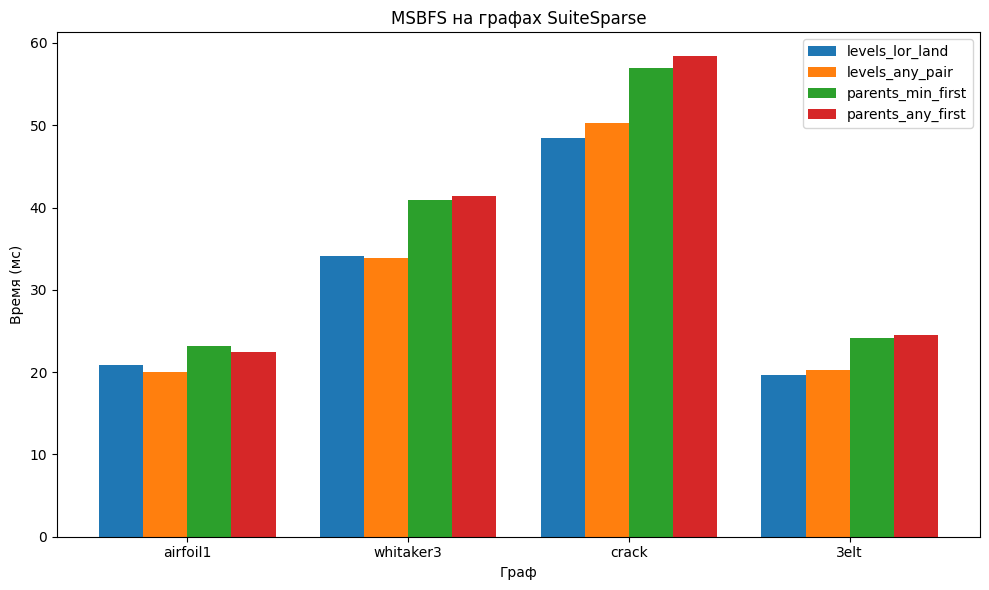

In [20]:
if len(df_ss) > 0:
    algo_cols = [c for c in df_ss.columns if c.endswith("_s") and c != "density"]
    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(df_ss))
    width = 0.2
    for i, col in enumerate(algo_cols):
        ax.bar([xi + i * width for xi in x], df_ss[col] * 1000, width, label=col.replace("_s", ""))
    ax.set_xlabel("Граф")
    ax.set_ylabel("Время (мс)")
    ax.set_title("MSBFS на графах SuiteSparse")
    ax.set_xticks([xi + width * 1.5 for xi in x])
    ax.set_xticklabels(df_ss["graph"])
    ax.legend()
    plt.tight_layout()
    plt.show()


## Задание 6 (+2 балла). Случайные графы

Три серии: меняем размер, плотность или число источников (остальное фиксировано).


### Зависимость от размера

`density=0.01`, 5 источников, `n ∈ {100, 500, 1000, 2000, 5000}`.


In [21]:
FIXED_DENSITY = 0.01
FIXED_SOURCES = 5
SIZES = [100, 500, 1000, 2000, 5000]

size_results = []
for n in SIZES:
    G = generate_random_directed_graph(n, FIXED_DENSITY, seed=n)
    sources = list(range(min(FIXED_SOURCES, n)))
    times = benchmark_msbfs(G, sources, n_runs=3)
    row = {"vertices": n, "density": FIXED_DENSITY, "n_sources": len(sources)}
    for algo_name, t in times.items():
        row[f"{algo_name}_s"] = t["mean_s"]
    size_results.append(row)

df_size = pd.DataFrame(size_results)
df_size


,vertices,density,n_sources,levels_lor_land_s,levels_any_pair_s,parents_min_first_s,parents_any_first_s
0,100,0.01,5,0.002128,0.001943,0.001998,0.002116
1,500,0.01,5,0.001791,0.001786,0.002448,0.002199
2,1000,0.01,5,0.002278,0.002210,0.002879,0.002919
3,2000,0.01,5,0.003423,0.003522,0.003933,0.003951
4,5000,0.01,5,0.006998,0.006475,0.008749,0.010083


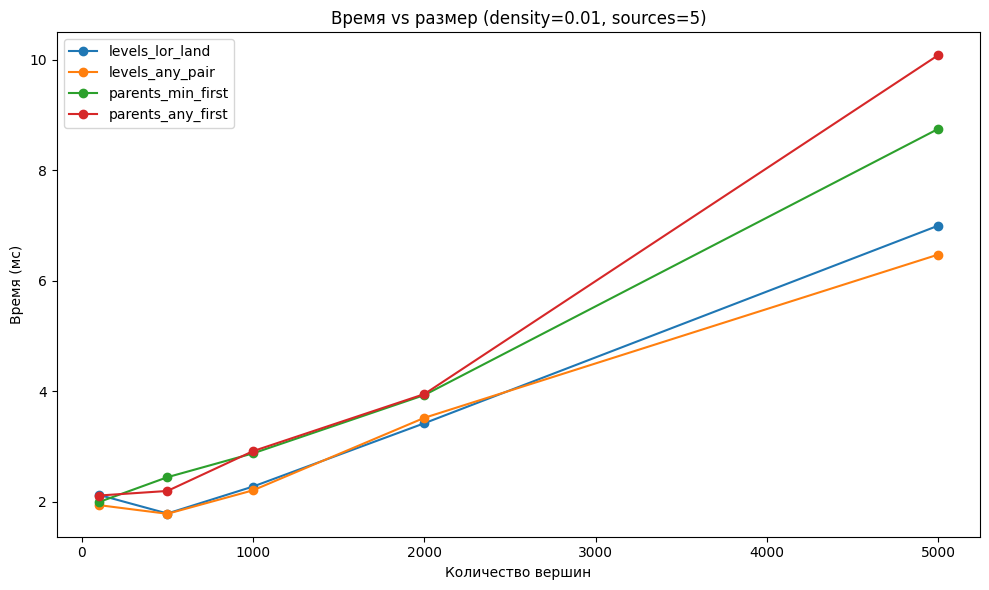

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for col in [c for c in df_size.columns if c.endswith("_s")]:
    ax.plot(df_size["vertices"], df_size[col] * 1000, marker="o", label=col.replace("_s", ""))
ax.set_xlabel("Количество вершин")
ax.set_ylabel("Время (мс)")
ax.set_title(f"Время vs размер (density={FIXED_DENSITY}, sources={FIXED_SOURCES})")
ax.legend()
plt.tight_layout()
plt.show()


### Зависимость от плотности

`n=1000`, 5 источников, `density ∈ {0.001, 0.005, 0.01, 0.05, 0.1}`.


In [23]:
FIXED_SIZE = 1000
DENSITIES = [0.001, 0.005, 0.01, 0.05, 0.1]

density_results = []
for d in DENSITIES:
    G = generate_random_directed_graph(FIXED_SIZE, d, seed=int(d * 100000))
    sources = list(range(min(FIXED_SOURCES, FIXED_SIZE)))
    times = benchmark_msbfs(G, sources, n_runs=3)
    row = {"vertices": FIXED_SIZE, "density": d, "n_sources": len(sources)}
    for algo_name, t in times.items():
        row[f"{algo_name}_s"] = t["mean_s"]
    density_results.append(row)

df_density = pd.DataFrame(density_results)
df_density


,vertices,density,n_sources,levels_lor_land_s,levels_any_pair_s,parents_min_first_s,parents_any_first_s
0,1000,0.001,5,0.001487,0.001213,0.001542,0.001662
1,1000,0.005,5,0.002827,0.002837,0.003757,0.004118
2,1000,0.010,5,0.002504,0.002562,0.003191,0.003216
3,1000,0.050,5,0.002777,0.002965,0.003316,0.003120
4,1000,0.100,5,0.002887,0.002089,0.002509,0.002743


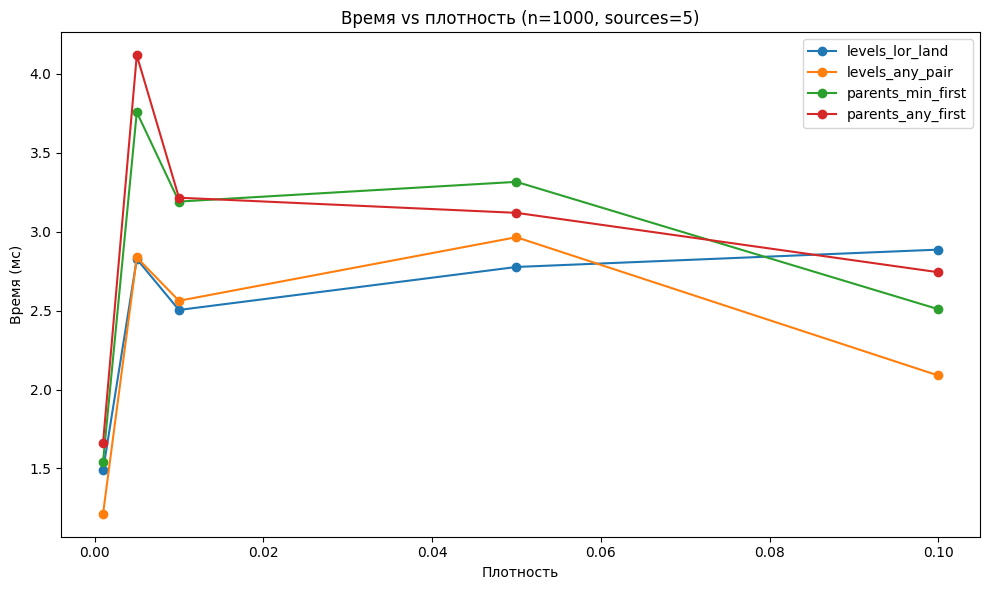

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
for col in [c for c in df_density.columns if c.endswith("_s")]:
    ax.plot(df_density["density"], df_density[col] * 1000, marker="o", label=col.replace("_s", ""))
ax.set_xlabel("Плотность")
ax.set_ylabel("Время (мс)")
ax.set_title(f"Время vs плотность (n={FIXED_SIZE}, sources={FIXED_SOURCES})")
ax.legend()
plt.tight_layout()
plt.show()


### Зависимость от числа источников

Один граф (`n=1000`, `density=0.01`), `k ∈ {1, 2, 5, 10, 20, 50, 100}`.


In [25]:
SOURCE_COUNTS = [1, 2, 5, 10, 20, 50, 100]
G_fixed = generate_random_directed_graph(FIXED_SIZE, FIXED_DENSITY, seed=42)

sources_results = []
for ns in SOURCE_COUNTS:
    sources = list(range(min(ns, FIXED_SIZE)))
    times = benchmark_msbfs(G_fixed, sources, n_runs=3)
    row = {"vertices": FIXED_SIZE, "density": FIXED_DENSITY, "n_sources": len(sources)}
    for algo_name, t in times.items():
        row[f"{algo_name}_s"] = t["mean_s"]
    sources_results.append(row)

df_sources = pd.DataFrame(sources_results)
df_sources


,vertices,density,n_sources,levels_lor_land_s,levels_any_pair_s,parents_min_first_s,parents_any_first_s
0,1000,0.01,1,0.000983,0.000844,0.001333,0.001204
1,1000,0.01,2,0.001229,0.001214,0.001699,0.001669
2,1000,0.01,5,0.002336,0.002298,0.002902,0.002703
3,1000,0.01,10,0.004379,0.004089,0.005027,0.004758
4,1000,0.01,20,0.007699,0.007671,0.009264,0.008200
5,1000,0.01,50,0.018058,0.017856,0.020432,0.019939
6,1000,0.01,100,0.035010,0.033482,0.038938,0.038381


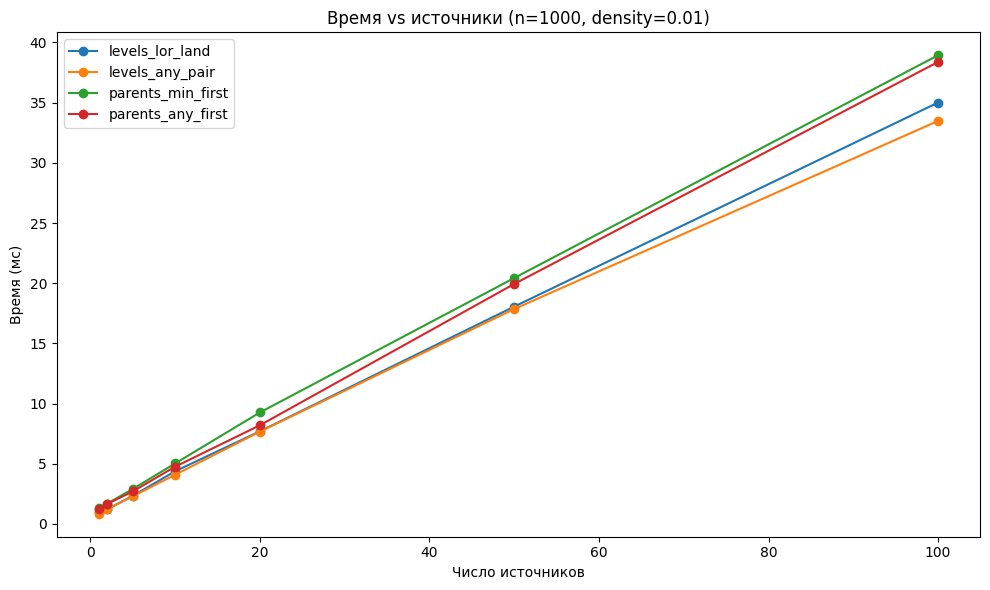

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
for col in [c for c in df_sources.columns if c.endswith("_s")]:
    ax.plot(df_sources["n_sources"], df_sources[col] * 1000, marker="o", label=col.replace("_s", ""))
ax.set_xlabel("Число источников")
ax.set_ylabel("Время (мс)")
ax.set_title(f"Время vs источники (n={FIXED_SIZE}, density={FIXED_DENSITY})")
ax.legend()
plt.tight_layout()
plt.show()


### Выводы

1. **Размер графа** (density=0.01, 5 источников): для `levels_lor_land` время растёт примерно от ~0.002 с (n=100) до ~0.007 с (n=5000). На отдельных n возможны колебания из-за случайной генерации графа (например, n=500 может быть быстрее n=100).

2. **Плотность** (n=1000, 5 источников): зависимость слабая и не всегда монотонная. В прогоне `levels_lor_land` менялся примерно от ~0.0015 с (density=0.001) до ~0.0029 с (density=0.1); основной рост заметен при переходе от очень разреженных графов к умеренной плотности.

3. **Число источников** (n=1000, density=0.01): время растёт с k, но не линейно по k. Для `levels_lor_land`: ~0.001 с при k=1, ~0.035 с при k=100 (рост ~35× при 100× источниках), то есть матричный MSBFS амортизирует накладные расходы.

4. **Сравнение полуколец:**
   - `any_pair` vs `lor.land`: на SuiteSparse разница в пределах нескольких процентов (airfoil1: 0.021 vs 0.020 с; crack: 0.048 vs 0.050 с). На случайных графах картина такая же.
   - `any_first` vs `min.first`: на SuiteSparse времена близки (airfoil1: 0.023 vs 0.022 с; crack: 0.057 vs 0.058 с). `any_first` не даёт стабильного выигрыша по скорости и не гарантирует минимального родителя, поэтому для parents предпочтительнее `min.first`.
